In [2]:
pairs=[]
with open('/kaggle/input/datasets/alincijov/bilingual-sentence-pairs/fra.txt', 'r', encoding='utf-8') as f:
    for line in f:
        t=line.strip().split('\t')
        if len(t)>=2:
            pairs.append((t[0], t[1]))
pairs=list(set(pairs))
print(f'всего пар: {len(pairs)}')
print(pairs[:5])

всего пар: 185583
[('When we hear of a divorce we assume that it was caused by the inability of those two people to agree upon fundamentals.', "Lorsque nous entendons parler d'un divorce, nous supposons qu'il a été causé par l'incapacité de ces deux personnes à s'entendre sur les fondamentaux."), ("You're first.", 'Vous êtes en premier.'), ('I was scared that you might leave me.', "J'avais peur que tu me quittes."), ('You gave me your word.', "Tu m'as donné ta parole."), ('They pitched their tents on the beach.', 'Ils ont dressé leurs tentes sur la plage.')]


In [3]:
from sklearn.model_selection import train_test_split

train, val=train_test_split(pairs, test_size=0.1, random_state=42)

print(f'train: {len(train)}')
print(f'val: {len(val)}')

train: 167024
val: 18559


In [4]:
src_words = set()
for eng, fra in pairs:
    for w in eng.split():
        src_words.add(w.lower())

src_w_i = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
for w in src_words:
    if w not in src_w_i:
        src_w_i[w] = len(src_w_i)
src_i_w = {v: k for k, v in src_w_i.items()}

tgt_words = set()
for eng, fra in pairs:
    for w in fra.split():
        tgt_words.add(w.lower())

tgt_w_i = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
for w in tgt_words:
    if w not in tgt_w_i:
        tgt_w_i[w] = len(tgt_w_i)
tgt_i_w = {v: k for k, v in tgt_w_i.items()}

print(f"английский словарь: {len(src_w_i)}")
print(f"французский словарь: {len(tgt_w_i)}")

английский словарь: 26747
французский словарь: 44084


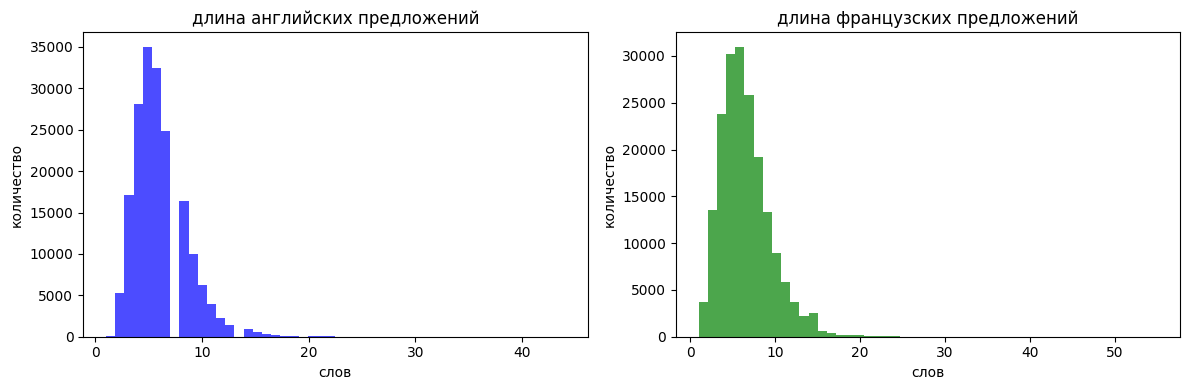

In [11]:
import matplotlib.pyplot as plt

src_len = [len(eng.split()) for eng, _ in pairs]
tgt_len = [len(fra.split()) for _, fra in pairs]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(src_len, bins=50, color='blue', alpha=0.7)
plt.title('длина английских предложений')
plt.xlabel('слов')
plt.ylabel('количество')

plt.subplot(1,2,2)
plt.hist(tgt_len, bins=50, color='green', alpha=0.7)
plt.title('длина французских предложений')
plt.xlabel('слов')
plt.ylabel('количество')

plt.tight_layout()

In [5]:
import torch
from torch.utils.data import DataLoader, Dataset

def sentence_i(sentence, w_i, max_len=8):
    words = sentence.split()
    idxs = [w_i.get(w.lower(), w_i['<UNK>']) for w in words]

    # обрезаем, если длиннее max_len-2 (для SOS и EOS)
    if len(idxs) > max_len - 2:
        idxs = idxs[:max_len-2]

    idxs = [w_i['<SOS>']] + idxs + [w_i['<EOS>']]

    # добавляем PAD до max_len
    if len(idxs) < max_len:
        idxs += [w_i['<PAD>']] * (max_len - len(idxs))

    return torch.tensor(idxs)

class TranslateDataset(Dataset):
  def __init__(self, pairs, src_wi, tgt_wi, max_len=8):
    self.pairs=pairs
    self.src_wi=src_wi
    self.tgt_wi=tgt_wi
    self.max_len=max_len

  def __len__(self):
    return len(self.pairs)

  def __getitem__(self,i):
    src, tgt=self.pairs[i]
    src_tensor=sentence_i(src, self.src_wi, self.max_len)
    tgt_tensor=sentence_i(tgt, self.tgt_wi, self.max_len)
    return src_tensor, tgt_tensor


train_dataset = TranslateDataset(train, src_w_i, tgt_w_i, 8)
val_dataset = TranslateDataset(val, src_w_i, tgt_w_i, 8)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(f'батчей train: {len(train_loader)},\nбатчей val: {len(val_loader)}')

батчей train: 1305,
батчей val: 145


In [6]:
import numpy as np
from torch.nn import Module, LSTM, Dropout, Linear, Embedding

class Encoder(Module):
  def __init__(self, vocab_size, embed_size, hidden_size):
    super().__init__()
    self.embedding=Embedding(vocab_size, embed_size)
    self.lstm=LSTM(embed_size, hidden_size, batch_first=True, bidirectional=True)
    self.dropout=Dropout(0.6)
    self.fc_hidden=Linear(hidden_size*2, hidden_size)
    self.fc_cell=Linear(hidden_size*2, hidden_size)


  def forward(self, x):
    x=self.embedding(x)
    x=self.dropout(x)
    outputs, (hidden, cell)=self.lstm(x)

    hidden=torch.cat((hidden[0], hidden[1]), dim=1) # (batch, hidden_size*2)
    cell=torch.cat((cell[0], cell[1]), dim=1) # (batch, hidden_size*2)

    hidden=self.fc_hidden(hidden).unsqueeze(0)  # (1, batch, hidden_size)
    cell=self.fc_cell(cell).unsqueeze(0)  # (1, batch, hidden_size)

    return outputs, hidden, cell


class Attention(Module):
  def __init__(self, hidden_size):
    super().__init__()
    self.attn=Linear(hidden_size*3, 1)

  def forward(self, hidden, encoder_outputs):
    hidden=hidden.permute(1,0,2)

    #копируем для каждого слова
    hidden=hidden.repeat(1,encoder_outputs.shape[1], 1)

    #объединяем и вычисляем веса
    x=torch.cat((hidden, encoder_outputs), dim=2)
    weights=self.attn(x).squeeze(2)

    return torch.softmax(weights, dim=1)



class Decoder(Module):
  def __init__(self,vocab_size, embed_size, hidden_size):
    super().__init__()
    self.embedding=Embedding(vocab_size, embed_size)
    self.attention=Attention(hidden_size)
    self.lstm=LSTM(embed_size+hidden_size*2, hidden_size, batch_first=True)
    self.fc_out=Linear(hidden_size*3 + embed_size, vocab_size)
    self.dropout=Dropout(0.6)

  def forward(self, input, hidden, cell, encoder_outputs):
    #input: (batch,)
    input=input.unsqueeze(1)
    input=self.dropout(self.embedding(input)) #(batch,1,embed_size)

    #внимание
    a=self.attention(hidden, encoder_outputs).unsqueeze(1) # (batch,1,src_len)
    w=torch.bmm(a, encoder_outputs) # (batch, 1, hidden_size*2)

    # lstm
    x=torch.cat((input,w),2) # (batch, 1, embed_size + hidden_size*2)
    output, (hidden, cell)=self.lstm(x, (hidden,cell))

    #предсказание
    output=output.squeeze(1) # (batch, hidden_size)
    w=w.squeeze(1) # (batch, hidden_size*2)
    input=input.squeeze(1) # (batch, embed_size)

    x=torch.cat((output, w, input), dim=1)  # (batch, hidden_size + hidden_size*2 + embed_size)

    return self.fc_out(x), hidden, cell


device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Seq2Seq(Module):
  def __init__(self, encoder, decoder, device):
    super().__init__()
    self.encoder=encoder
    self.decoder=decoder
    self.device=device

  def forward(self, src,tgt, teacher_forcing_ratio=0.5):
    batch_size=src.shape[0]
    tgt_len=tgt.shape[1]
    tgt_vocab_size=self.decoder.fc_out.out_features # получаем размер словаря целевого языка из выходного слоя декодера

    # тензор из нулей, куда будем складывать предсказания модели на каждом шаге
    outputs=torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

    # кодируем исходное предложение
    encoder_outputs, hidden, cell= self.encoder(src)

    input=tgt[:,0]

    # генерируем перевод по словам
    for t in range(1, tgt_len):
      output, hidden, cell= self.decoder(input, hidden, cell, encoder_outputs)
      outputs[:,t,:]=output

      # с вероятностью teacher_forcing_ratio используем правильное слово
      if np.random.random() < teacher_forcing_ratio:
        input = tgt[:, t] # берем правильное слово
      else:
        input = output.argmax(1) # берем предсказание

    return outputs

In [7]:
from tqdm import tqdm

encoder=Encoder(len(src_w_i), 128, 128)
decoder=Decoder(len(tgt_w_i), 128, 128)

model=Seq2Seq(encoder, decoder, device).to(device)

optimizer=torch.optim.Adam(model.parameters(), lr=0.0005)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
loss_f=torch.nn.CrossEntropyLoss()

best_val_loss=float('inf')
patience=3
patience_counter=0

for epoch in range(10):
  model.train()
  train_loss=0
  for src, tgt in tqdm(train_loader, desc=f'epoch {epoch+1} train'):
    src, tgt=src.to(device), tgt.to(device)
    optimizer.zero_grad()
    output=model(src, tgt)

    # изменяем форму, чтобы loss сравнивал каждое слово отдельно
    loss=loss_f(output.view(-1,len(tgt_w_i)), tgt.view(-1))
    train_loss+=loss.item()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
    optimizer.step()

  model.eval()
  val_loss=0
  with torch.no_grad():
    for src, tgt in tqdm(val_loader, desc=f'epoch {epoch+1} val'):
      src, tgt= src.to(device), tgt.to(device)
      output=model(src, tgt, teacher_forcing_ratio=0)
      loss=loss_f(output.view(-1,len(tgt_w_i)), tgt.view(-1))
      val_loss+=loss.item()

  avg_train_loss=train_loss/len(train_loader)
  avg_val_loss=val_loss/len(val_loader)

  scheduler.step(avg_val_loss)

  print(f"epoch {epoch+1}: train Loss = {avg_train_loss:.3f}, val Loss = {avg_val_loss:.3f}")

  if avg_val_loss<best_val_loss:
    best_val_loss=avg_val_loss
    torch.save(model.state_dict(), 'best_model_translate.pth')
  else:
    patience_counter += 1
    if patience_counter >= patience:
      print(f"ранняя остановка на эпохе {epoch+1}")
      break

epoch 1 val: 100%|██████████| 145/145 [01:25<00:00,  1.70it/s]


epoch 1: train Loss = 5.456, val Loss = 4.874


epoch 2 val: 100%|██████████| 145/145 [01:28<00:00,  1.64it/s]


epoch 2: train Loss = 4.534, val Loss = 4.492


epoch 3 val: 100%|██████████| 145/145 [01:25<00:00,  1.71it/s]


...

epoch 8: train Loss = 3.397, val Loss = 3.928


epoch 9 val: 100%|██████████| 145/145 [01:31<00:00,  1.58it/s]


epoch 9: train Loss = 3.318, val Loss = 3.895


epoch 10 val: 100%|██████████| 145/145 [01:53<00:00,  1.28it/s]


epoch 10: train Loss = 3.243, val Loss = 3.877


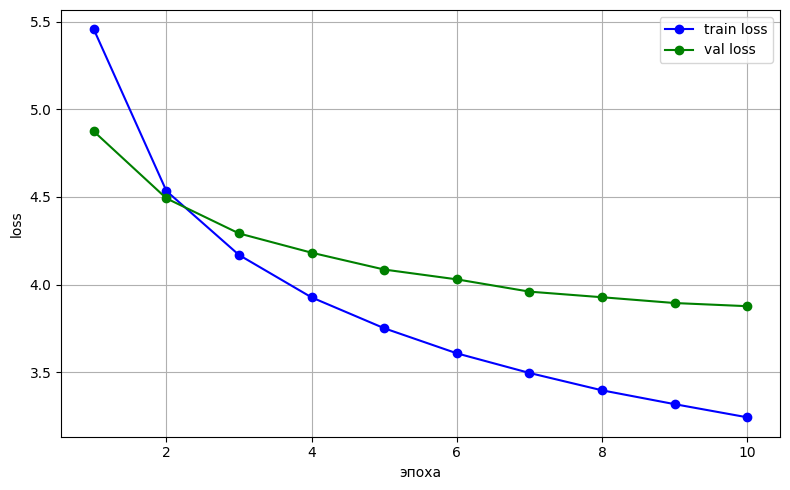

In [13]:
epochs = list(range(1, 11))
train_losses = [5.456, 4.534, 4.169, 3.927, 3.751, 3.608, 3.496, 3.397, 3.318, 3.243]
val_losses = [4.874, 4.492, 4.292, 4.182, 4.086, 4.030, 3.960, 3.928, 3.895, 3.877]

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses, 'b-o', label='train loss')
plt.plot(epochs, val_losses, 'g-o', label='val loss')
plt.xlabel('эпоха')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

In [14]:
model.load_state_dict(torch.load('best_model_translate.pth'))
model.eval()

def translate(text, max_len=9):
  with torch.no_grad():
    tokens=sentence_i(text, src_w_i, max_len).unsqueeze(0).to(device)
    encoder_outputs, hidden, cell=model.encoder(tokens)
    input=torch.tensor([tgt_w_i['<SOS>']]).to(device)
    translated=[]
    for i in range(max_len):
      output, hidden, cell= model.decoder(input, hidden, cell, encoder_outputs)
      pred=output.argmax(1).item()
      if pred==tgt_w_i['<EOS>']:
        break
      if pred not in [tgt_w_i['<PAD>'], tgt_w_i['<SOS>']]:
        translated.append(tgt_i_w[pred])

      input=torch.tensor([pred]).to(device)
    return ' '.join(translated)

test_phrases = [
    "hello",
    "how are you",
    "i love you",
    "what is your name",
    "good morning"
]

print("переводы:")
for phrase in test_phrases:
    print(f'англ: {phrase}')
    print(f'франц: {translate(phrase)}\n')

переводы:
англ: hello
франц: salut !

англ: how are you
франц: comment êtes-vous ? ?

англ: i love you
франц: j'adore t'aime

англ: what is your name
франц: quelle est votre nom ?

англ: good morning
франц: bon bon !

